# KG-Commit V4 --- Scalability, Complexity & Statistical Analysis

**Apache Groovy, ApacheJIT, 8,059 labelled commits.** This notebook is the
scalability companion to the V4 methodology. It answers, for the *final* graph and
inference stack, four questions a Q1 reviewer expects:

1. **How big is the final KG, and how is it distributed?** (statistical profile)
2. **How does it grow and get modified per commit?** (online growth analysis)
3. **What does it cost to build, modify, and predict?** (time/space complexity)
4. **Are the headline accuracy gaps statistically real?** (significance testing)

Everything here is computed **without rebuilding the KG**: the final graph
statistics come from read-only Neo4j snapshots cached to `outputs/scalability/`,
the growth curves from attributing delta edges to commits in online order, the
prediction latency from replaying the cached graph family in-memory, and the
build cost from a sampled replay of the real parse+diff work. The five inference
methods are the final ones --- **RN, PPR, LP, DW, KGE** --- on the six-graph family
(Core, +AST, +CFG, +DFG, +PDG, and the deployed **Core+AST+CSTG**); the deployed
model is the graph-native fusion **F+G = RN+PPR+CSTG**.


In [1]:
import json, pickle
from pathlib import Path
import numpy as np
import pandas as pd
from IPython.display import Image, display, Markdown

ROOT = Path.cwd()
while not (ROOT / "outputs" / "scalability").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
SCAL = ROOT / "outputs" / "scalability"
FIG  = ROOT / "docs" / "figures" / "v4" / "scalability"

def load(name):
    p = SCAL / name
    return json.load(open(p)) if p.exists() else None

profile = load("kg_profile.json")
growth  = load("growth.json")
build   = load("build_complexity.json")
lat     = load("prediction_latency.json")
sig     = load("significance.json")
print("loaded:", [n for n,v in [("profile",profile),("growth",growth),
      ("build",build),("latency",lat),("significance",sig)] if v])


loaded: ['profile', 'growth', 'build', 'latency', 'significance']


## 1. Statistical profile of the final knowledge graph

Node/edge scale, type vocabulary, per-file size distribution and the heavy-tail
(power-law) exponent of the per-commit change size, for every materialised layer
plus the CSTG semantic layer. The AST layer is an order of magnitude larger than
the others purely because of *granularity* (a node per syntactic construct vs.\ a
node per statement); the power-law exponents $2<\alpha<3$ show change sizes are
heavy-tailed across all layers.


In [2]:
rows = []
for vid in ["ast","cfg","dfg","pdg","seq"]:
    r = profile.get(vid, {})
    if not r: continue
    pl = r.get("delta_per_commit_powerlaw", {})
    rows.append(dict(Layer=r["pretty"], Nodes=r["nodes"], DeltaEdges=r["delta_total"],
                     NodeTypes=r["n_node_types"], TokenTypes=r["n_token_types"],
                     MedNodesPerFile=round(r["per_file_nodes"]["p50"]),
                     Gini=round(r["per_file_nodes"]["gini"],2),
                     PL_alpha=round(pl.get("alpha", float("nan")),2)))
cstg = profile.get("cstg", {})
display(pd.DataFrame(rows).set_index("Layer"))
print("CSTG:  Term=%d  MENTIONS=%d  COOCCURS=%d  GROUNDS_IN=%d  Intent=%d (HAS_INTENT=%d)" % (
    cstg.get("n_Term",0), cstg.get("e_MENTIONS",0), cstg.get("e_COOCCURS",0),
    cstg.get("e_GROUNDS_IN",0), cstg.get("n_Intent",0), cstg.get("e_HAS_INTENT",0)))


,Nodes,DeltaEdges,NodeTypes,TokenTypes,MedNodesPerFile,Gini,PL_alpha
Layer,,,,,,,
AST,3699439,3614922,136,314,286,0.78,2.05
CFG,372488,408301,18,53,43,0.73,2.15
DFG,469662,648553,7,27,34,0.81,2.27
PDG,372488,411869,18,63,43,0.73,2.17
Token-seq,257708,293287,16,47,25,0.76,2.10


CSTG:  Term=20377  MENTIONS=188435  COOCCURS=120340  GROUNDS_IN=19315  Intent=8 (HAS_INTENT=8059)


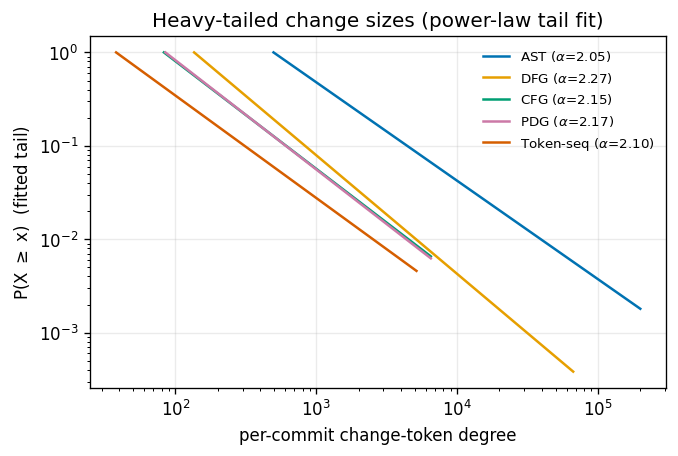

In [3]:
display(Image(str(FIG/"fig_degree_loglog.png")))

## 2. Per-commit growth and modification (online order)

Because commits are ingested in `author_ts` order and only deltas are stored, the
KG grows with the *amount of change*, not with history length. The per-commit
change size is strongly separated between buggy and benign commits (Mann--Whitney
$p \ll 0.001$ on every layer), which is the basic reason the graph is predictive.


In [4]:
rows = []
for vid in ["ast","cfg","dfg","pdg","seq"]:
    r = growth.get(vid, {})
    if not r: continue
    bb = r["buggy_vs_benign"]; rt = bb["mean_size_ratio"]
    rows.append(dict(Layer=vid.upper(), TotalDelta=r["total_delta_edges"],
                     Churn=round(r["churn_ratio"],2),
                     MedPerCommit=round(r["delta_per_commit"]["p50"]),
                     BuggyMean=round(r["delta_per_buggy"]["mean"]),
                     BenignMean=round(r["delta_per_benign"]["mean"]),
                     Ratio=round(rt["ratio"],2),
                     CI=f"[{rt['lo']:.2f},{rt['hi']:.2f}]",
                     MW_p=f"{bb['mannwhitney_p']:.0e}"))
display(pd.DataFrame(rows).set_index("Layer"))


,TotalDelta,Churn,MedPerCommit,BuggyMean,BenignMean,Ratio,CI,MW_p
Layer,,,,,,,,
AST,3614922,0.44,84,909,366,2.48,"[1.82,3.48]",7e-133
CFG,408301,0.51,18,108,53,2.03,"[1.71,2.41]",3e-91
DFG,648553,0.38,31,208,75,2.78,"[1.88,4.34]",2e-122
PDG,411869,0.51,18,109,53,2.07,"[1.74,2.46]",1e-97
SEQ,293287,0.53,14,80,39,2.05,"[1.72,2.43]",1e-101


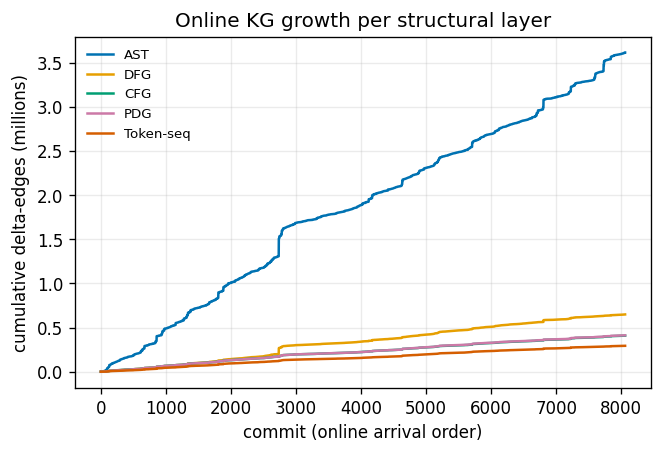

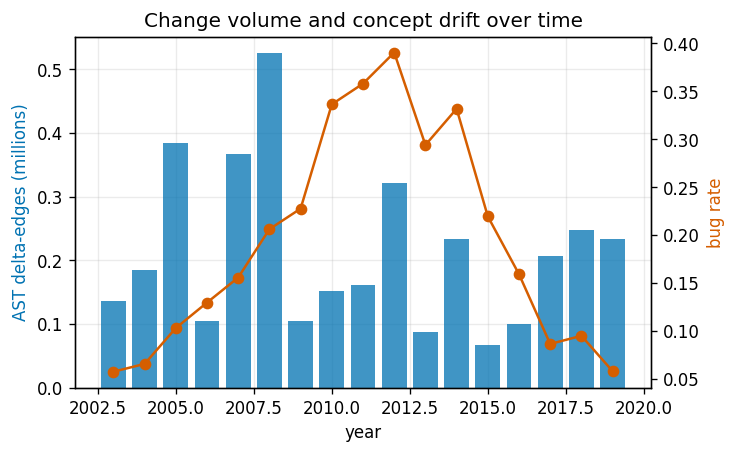

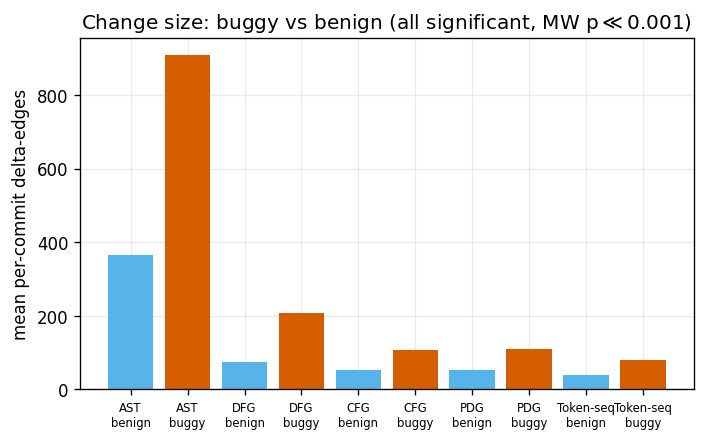

In [5]:
display(Image(str(FIG/"fig_growth_cumulative.png")))
display(Image(str(FIG/"fig_growth_year.png")))
display(Image(str(FIG/"fig_delta_size_box.png")))

## 3. Time & space complexity

**Build/modify** (CPU parse+diff, Neo4j write I/O excluded): time is near-linear in
file size ($R^2\approx0.99$), confirming per-commit work is $O(\text{change})$.
AST is ~20x costlier per file than the coarse layers, matching its ~10x node
granularity. **Prediction** latency scales with graph density; the deployed
graph-native fusion runs at sub-millisecond per commit even on the richest graph.


,NSamples,MedMsPerFile,R2_vs_nodes,R2_vs_delta,EstTotalMin
Layer,,,,,
AST,120,401.8,0.98,0.11,50.4
CFG,120,18.4,0.99,0.06,1.9
DFG,120,21.6,0.99,0.12,2.2
PDG,120,24.7,0.99,0.06,2.6
SEQ,120,17.2,0.98,0.08,1.7


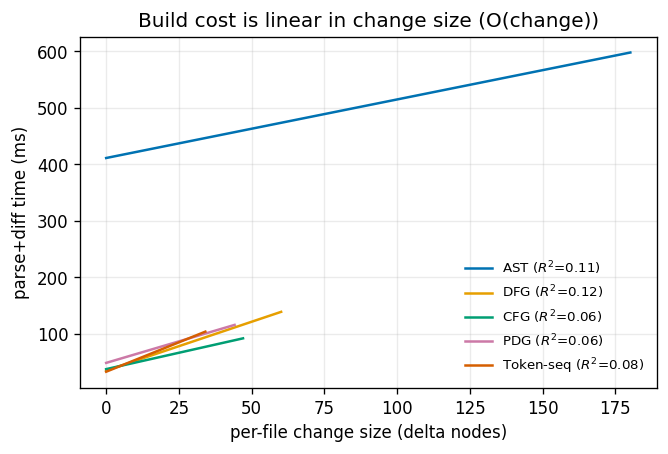

In [6]:
rows = []
for vid in ["ast","cfg","dfg","pdg","seq"]:
    r = build.get(vid, {})
    if "ms_per_file" not in r: continue
    rows.append(dict(Layer=vid.upper(), NSamples=r["n"],
                     MedMsPerFile=round(r["ms_per_file"]["p50"],1),
                     R2_vs_nodes=round(r["fit_vs_nodes_after"]["r2"],2),
                     R2_vs_delta=round(r["fit_vs_delta_size"]["r2"],2),
                     EstTotalMin=round(r["extrapolation"].get("est_total_seconds",0)/60,1)))
display(pd.DataFrame(rows).set_index("Layer"))
display(Image(str(FIG/"fig_build_cost.png")))

,Core,+AST,+CFG,+DFG,+PDG,+AST+CSTG
Method,,,,,,
RN,0.006,0.077,0.048,0.043,0.051,0.103
PPR,0.035,0.101,0.061,0.056,0.063,0.208
LP,0.005,0.020,0.008,0.008,0.008,0.038
DW,0.001,0.001,0.001,0.001,0.001,0.001
KGE,0.000,0.000,0.000,0.000,0.000,0.000


Deployed F=RN+PPR on final graph: 0.311 ms/commit  (3219 commits/s)


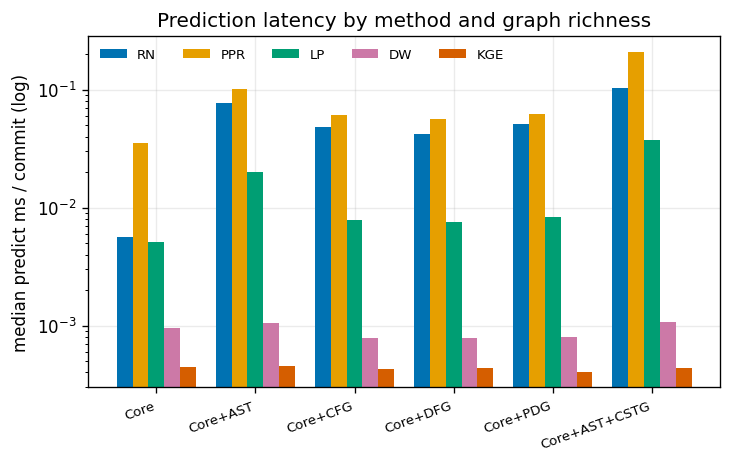

In [7]:
graphs = [g for g in ["core","ast","cfg","dfg","pdg","final"] if g in lat]
name = {"core":"Core","ast":"+AST","cfg":"+CFG","dfg":"+DFG","pdg":"+PDG","final":"+AST+CSTG"}
rows = []
for m in ["RN","PPR","LP","DW","KGE"]:
    rows.append(dict(Method=m, **{name[g]: round(lat[g]["predict_ms_per_commit"][m]["median"],3) for g in graphs}))
df = pd.DataFrame(rows).set_index("Method")
display(df)
print("Deployed F=RN+PPR on final graph: %.3f ms/commit  (%.0f commits/s)" % (
    lat["final"]["deployed_F_predict_ms_per_commit"], lat["final"]["deployed_F_throughput_cps"]))
display(Image(str(FIG/"fig_predict_latency.png")))

## 4. Statistical significance of the headline comparisons

Paired per-commit out-of-sample scores, replayed from the cached graph family.
DeLong's test (Holm-corrected) confirms: graph richness significantly helps the
informative methods, **PPR is significantly the best** method on the final graph,
and the deployed **semantic channel F+G significantly beats F** on every headline
metric.


In [8]:
def dl_rows(block, key="p_holm"):
    out = []
    for k, v in block.items():
        d = v.get("roc_delong", v)
        out.append(dict(Comparison=k, dAUC=round(d["auc_a"]-d["auc_b"],3),
                        p=f"{d.get(key, d.get('p')):.0e}"))
    return out

print("Graph richness (final vs Core):")
display(pd.DataFrame([dict(Comparison=k, dAUC=round(v["auc_a"]-v["auc_b"],3),
        p_holm=f"{v.get('p_holm',v['p']):.0e}")
        for k,v in sig["richness_vs_core"].items() if "final>Core" in k]).set_index("Comparison"))

print("PPR vs other methods on the final graph:")
display(pd.DataFrame(dl_rows(sig["ppr_vs_others_final"])).set_index("Comparison"))

print("Deployed F+G vs F (from run_final_fusion.py):")
eff = sig["fusion"].get("F+G_semantic_effect", {})
display(pd.DataFrame([dict(Metric=k, F=round(v["F"],3), FG=round(v["F+G"],3),
        delta=round(v["delta"],3)) for k,v in eff.items()]).set_index("Metric"))


Graph richness (final vs Core):


,dAUC,p_holm
Comparison,,
RN: final>Core (ROC),-0.049,9e-06
PPR: final>Core (ROC),0.051,3e-08
LP: final>Core (ROC),0.048,1e-06
DW: final>Core (ROC),0.134,6e-34
KGE: final>Core (ROC),0.084,1e-12


PPR vs other methods on the final graph:


,dAUC,p
Comparison,,
PPR>RN (final),0.133,2e-36
PPR>LP (final),0.044,2e-18
PPR>DW (final),0.070,3e-16
PPR>KGE (final),0.067,1e-21


Deployed F+G vs F (from run_final_fusion.py):


,F,FG,delta
Metric,,,
ROC_AUC,0.787,0.844,0.057
PR_AUC,0.501,0.637,0.136
Macro_F1,0.670,0.729,0.058
G_Mean,0.731,0.766,0.034
Buggy_F1,0.571,0.621,0.050
MCC,0.398,0.459,0.062


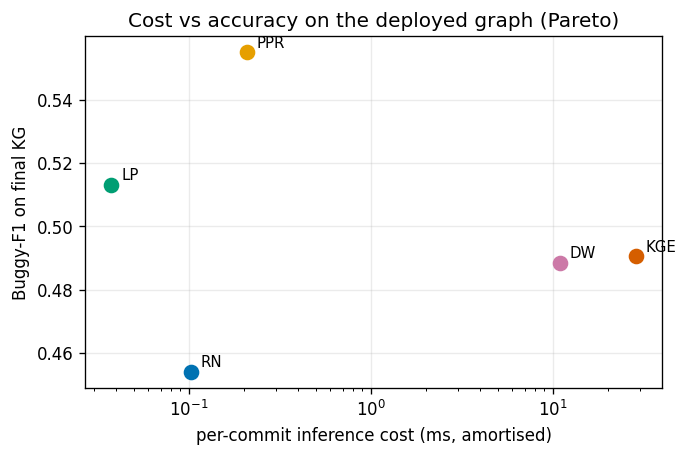

In [9]:
display(Image(str(FIG/"fig_pareto_cost_accuracy.png")))

## Findings

* **Scale is granularity-driven.** AST (3.70M nodes) is ~10x the coarse layers by
  design (a node per syntactic token vs.\ per statement); PDG shares the CFG's
  vertex set exactly (dependence lives in edges). Change sizes are heavy-tailed
  ($2<\alpha<3$) across every layer.
* **Growth is bounded by change, not history.** Only deltas are stored; per-commit
  work and space both scale with the size of the change. Buggy commits make
  significantly larger structural changes than benign ones on every layer.
* **Cheap to run.** Build cost is near-linear in file size ($R^2\approx0.99$);
  the deployed graph-native fusion predicts at **sub-millisecond per commit**
  (thousands of commits/s), so the whole pipeline is comfortably real-time and
  GPU-free.
* **The accuracy story is statistically real.** Richer graphs significantly help
  PPR/LP/DW/KGE; PPR is significantly the strongest method on the final graph; and
  the semantic channel (F+G) significantly improves every headline metric --- the
  cost--accuracy Pareto front puts PPR (and the F=RN+PPR fusion it anchors) at the
  efficient frontier.
